# Torus PPH — Examples

This notebook walks through a few torus persistent path-homology configurations using `torus_pph`.
We build graphs, draw them, compute their persistence diagrams, and compare a couple of variants.

## Setup
Imports and inline plotting.

In [1]:
%matplotlib widget

In [19]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from torus_pph import (
    Config,
    build_graph,
    analyze_simple,
    plot_torus_graph,
    plot_persistence_diagram,
    plot_height_function,
    plot_torus_3d,
    analyze,
)

## Configurations
Four torus graph configurations we'll use throughout the notebook.

In [5]:
CONFIGS = [
    dict(n=5,  height_variant='sin_theta'),
    dict(n=5, height_variant='sin_plus_sin'),
    dict(n=5, height_variant='quarter_triangle'),
    dict(n=5, height_variant='saddle'),
]
for c in CONFIGS:
    cfg = Config(**c)
    print(cfg)

Config(n=5, m=None, height_variant='sin_theta', double_edges=True, R=2.0, r=1.0, sampling='grid', jitter_std=0.3, random_seed=None)
Config(n=5, m=None, height_variant='sin_plus_sin', double_edges=True, R=2.0, r=1.0, sampling='grid', jitter_std=0.3, random_seed=None)
Config(n=5, m=None, height_variant='quarter_triangle', double_edges=True, R=2.0, r=1.0, sampling='grid', jitter_std=0.3, random_seed=None)
Config(n=5, m=None, height_variant='saddle', double_edges=True, R=2.0, r=1.0, sampling='grid', jitter_std=0.3, random_seed=None)


## Build and visualize the torus graphs
For each configuration we call `build_graph` (to inspect the resulting `DiGraph`) and `plot_torus_graph` (to draw it in the (θ, φ) parameter square).

## Persistence diagrams
For each configuration above, run `analyze_simple` and plot the persistence diagram. The barcode is printed below each diagram in units of π.

In [29]:
def barcode_in_pi(result):
    out = []
    for b, d in result.barcode:
        b_pi = f'{b/np.pi:.3f}π'
        d_pi = '∞' if not np.isfinite(d) else f'{d/np.pi:.3f}π'
        out.append((b_pi, d_pi))
    return out

In [ ]:
c = Config(n=25, height_variant='sin_theta', double_edges=True)
result = analyze(c)
plot_persistence_diagram(result)
plt.show()
print('barcode (π units):')
for b, d in barcode_in_pi(result):
    print(f'  ({b}, {d})')

## Comparison: `double_edges=False` vs `double_edges=True`
Same configuration (n=5, sin_theta), two flavors of edge orientation. Diagrams shown side by side.

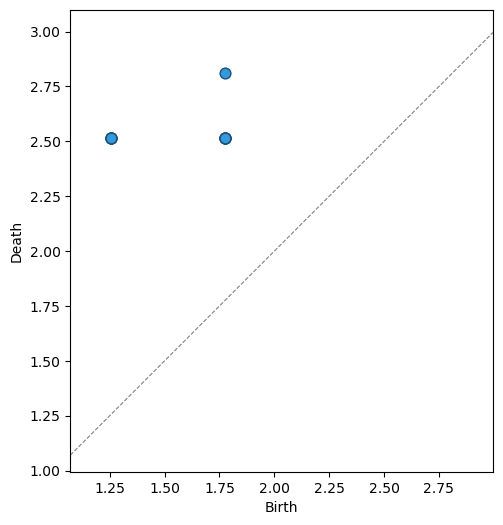

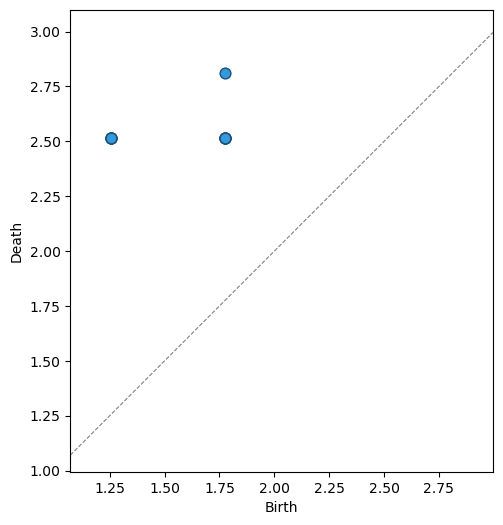

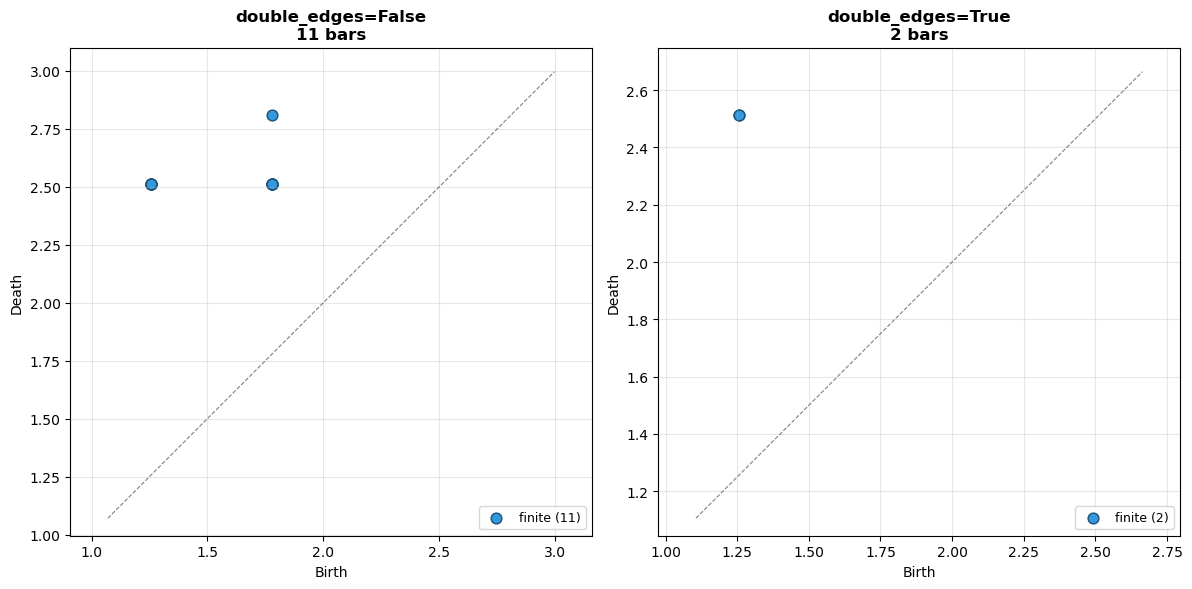

double_edges=False: 11 bars
double_edges=True : 2 bars


In [81]:
res_no  = analyze_simple(n=5, height_variant='sin_theta', double_edges=False)
res_yes = analyze_simple(n=5, height_variant='sin_theta', double_edges=True)

fig = plt.figure(figsize=(12, 6))
for i, (res, label) in enumerate([(res_no, 'double_edges=False'), (res_yes, 'double_edges=True')]):
    ax = plt.subplot(1, 2, i + 1)
    finite   = [(b, d) for b, d in res.barcode if np.isfinite(d)]
    infinite = [b for b, d in res.barcode if not np.isfinite(d)]
    all_vals = [b for b, d in finite] + [d for b, d in finite] + infinite
    lo, hi = min(all_vals, default=0.0), max(all_vals, default=1.0)
    pad = (hi - lo) * 0.12 if hi > lo else 0.5
    lo -= pad; hi += pad
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
    if finite:
        bs, ds = zip(*finite)
        ax.scatter(bs, ds, s=60, facecolors='#3498db', edgecolors='#1a5276',
                   label=f'finite ({len(finite)})')
    if infinite:
        ax.scatter(infinite, [hi - pad * 0.3] * len(infinite),
                   s=80, marker='^', facecolors='#e74c3c', edgecolors='#922b21',
                   label=f'infinite ({len(infinite)})')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi + pad * 0.15)
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_title(f'{label}\n{res.n_bars} bars', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'double_edges=False: {res_no.n_bars} bars')
print(f'double_edges=True : {res_yes.n_bars} bars')

## Height function landscapes
Heatmaps of the four height functions used above, drawn directly on the (θ, φ) torus chart.

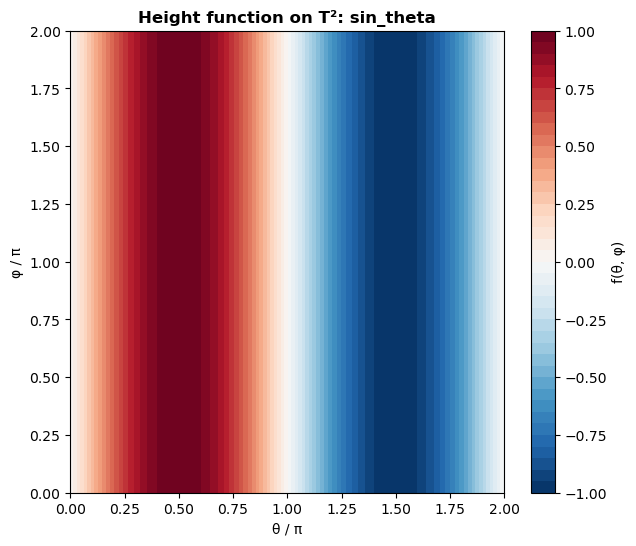

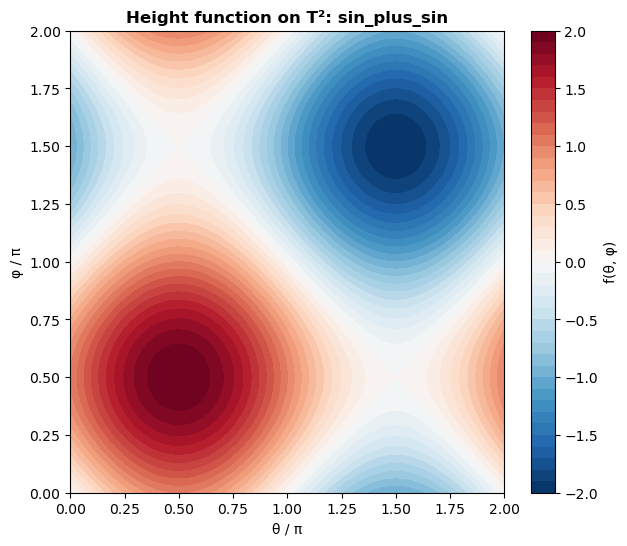

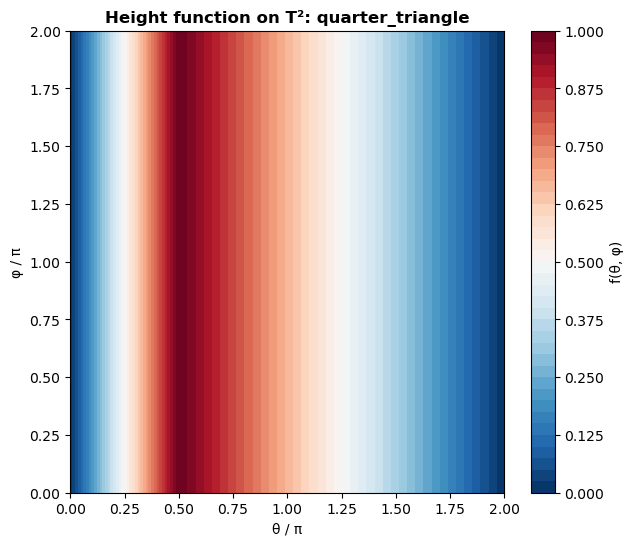

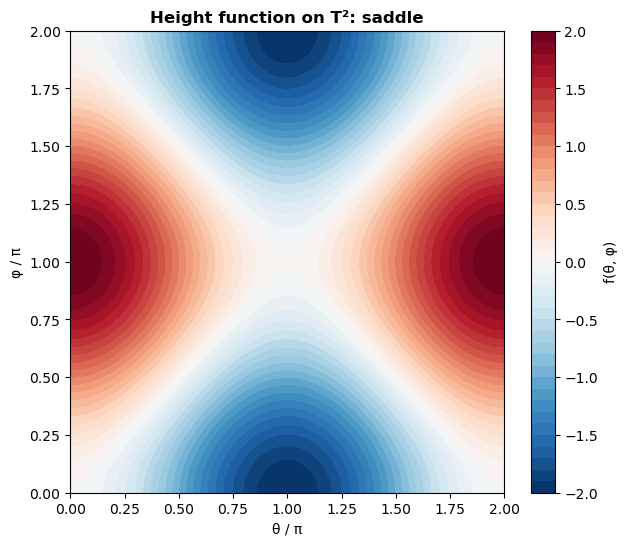

In [18]:
for cfg_dict in CONFIGS:
    plot_height_function(variant=cfg_dict['height_variant'])
    plt.show()

In [49]:
from torus_pph import analyze, Config
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

all_variants = [
    # 3D embedding
    'sin_theta'
]

n_range = range(16, 25)
cmap = cm.viridis
norm = plt.Normalize(vmin=min(n_range), vmax=max(n_range))

chunk_size = 5
chunks = [all_variants[i:i+chunk_size] for i in range(0, len(all_variants), chunk_size)]

for chunk in chunks:
    fig, axes = plt.subplots(1, len(chunk), figsize=(4 * len(chunk), 5))
    if len(chunk) == 1:
        axes = [axes]
    fig.suptitle('Torus PPH Persistence Diagrams (double_edges=True)', fontweight='bold')

    for ax, variant in zip(axes, chunk):
        ax.plot([0, np.pi], [0, np.pi], 'k--', lw=0.8, alpha=0.4)
        for n in n_range:
            cfg = Config(n=n, height_variant=variant, double_edges=True)
            r = analyze(cfg)
            color = cmap(norm(n))
            for birth, death in r.barcode:
                if np.isfinite(death):
                    ax.scatter(birth, death, color=color, s=30, alpha=0.8, zorder=3)
                else:
                    ax.scatter(birth, np.pi * 1.05, color=color, marker='^', s=50, zorder=3)

        ax.set_title(variant, fontsize=9)
        ax.set_xlabel('birth', fontsize=8)
        ax.set_ylabel('death', fontsize=8)
        ax.set_xlim(-0.1, np.pi * 1.1)
        ax.set_ylim(-0.1, np.pi * 1.2)
        ax.set_xticks([0, np.pi / 2, np.pi])
        ax.set_xticklabels(['0', 'π/2', 'π'], fontsize=7)
        ax.set_yticks([0, np.pi / 2, np.pi])
        ax.set_yticklabels(['0', 'π/2', 'π'], fontsize=7)
        ax.grid(True, alpha=0.3)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label='n', shrink=0.8)
    plt.subplots_adjust(left=0.05, right=0.9, top=0.88, bottom=0.12, wspace=0.35)
    plt.show()

KeyboardInterrupt: 